In [1]:
import torch
import timm
import os
import json
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = '/kaggle/input/datasets/madhusatyala/gnr638-bestmodels'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Using device: {DEVICE}")

def get_model(model_name, num_classes=30):
    model = timm.create_model(model_name, pretrained=True)
    if 'resnet' in model_name:
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif 'efficientnet' in model_name:
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif 'convnext' in model_name:
        model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)
    
    model = model.to(DEVICE)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    return model

Using device: cuda


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Define standard transforms (ImageNet normalization is standard for timm models)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the full dataset (Assuming you downloaded/unzipped it to /kaggle/working/data/AID)
# Replace with your actual path
data_dir = '/kaggle/input/datasets/adarshguduru/gnr638-ass2/train_data' 
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 3. Stratified Split (80% Train, 20% Val)
# Note: For the assignment, use a fixed seed for reproducibility!
seed = 42 
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], 
                                          generator=torch.Generator().manual_seed(seed))

# 4. DataLoaders (Optimized for 2 GPUs)
# Since you have 2 GPUs, you can double your batch size safely.
batch_size = 64 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Classes: {len(full_dataset.classes)} | Total Images: {len(full_dataset)}")

Classes: 30 | Total Images: 6993


In [3]:
import torch
import torchvision.transforms.functional as TF
import numpy as np
import pandas as pd
from collections import OrderedDict

def apply_corruption(batch, c_type, severity):
    """Applies corruptions to a batch of tensors (B, C, H, W) at eval time."""
    if c_type == 'noise':
        # severity is sigma
        return batch + torch.randn_like(batch) * severity
    
    elif c_type == 'blur':
        # severity is kernel size (must be odd)
        k = int(severity)
        return TF.gaussian_blur(batch, [k, k])
    
    elif c_type == 'brightness':
        # severity is factor (0.5 is darker, 1.5 is brighter)
        return TF.adjust_brightness(batch, severity)
    
    return batch

def run_4_4_robustness(model, model_label, loader):
    model.eval()
    # Defined severities as per assignment requirements
    corruptions = {
        'noise': [0.05, 0.1, 0.2],
        'blur': [3, 5, 7],
        'brightness': [1, 1.5, 2]
    }
    
    print(f"Starting Robustness Evaluation for {model_label}...")
    
    # 1. Baseline Accuracy (Clean)
    clean_correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            clean_correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    
    acc_clean = clean_correct / total
    print(f"Clean Accuracy: {acc_clean*100:.2f}%")
    
    robustness_results = []

    # 2. Corrupted Evaluation
    for c_name, severities in corruptions.items():
        for sev in severities:
            correct = 0
            with torch.no_grad():
                for imgs, labels in loader:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    # Apply corruption only at evaluation time
                    corrupted_imgs = apply_corruption(imgs, c_name, sev)
                    outputs = model(corrupted_imgs)
                    correct += (outputs.argmax(1) == labels).sum().item()
            
            acc_corr = correct / total
            
            # CALCULATIONS REQUIRED BY 4.4:
            ce = 1 - acc_corr  # Corruption Error
            rr = acc_corr / acc_clean  # Relative Robustness
            
            robustness_results.append({
                'Model': model_label,
                'Corruption': c_name,
                'Severity': sev,
                'Acc_Corrupted': f"{acc_corr*100:.2f}%",
                'Corruption_Error': round(ce, 4),
                'Rel_Robustness': round(rr, 4)
            })
            print(f"  > {c_name} (sev {sev}): Acc={acc_corr*100:.2f}% | CE={ce:.4f} | RR={rr:.4f}")

    return pd.DataFrame(robustness_results)



In [4]:
import torch
import torchvision.transforms.functional as TF
import numpy as np
import pandas as pd
from collections import OrderedDict

# Define paths to your specific saved weights
# Ensure these paths point to where your .pth files are stored
model_paths = {
    'ConvNeXt': '/kaggle/input/datasets/madhusatyala/gnr638-bestmodels/ConvNeXt_full_best (1).pth',
    'ResNet50': '/kaggle/input/datasets/madhusatyala/gnr638-bestmodels/ResNet50_full_best.pth', # Adjust path if needed
    'EffNetB0': '/kaggle/input/datasets/madhusatyala/gnr638-bestmodels/EffNetB0_full_best.pth'  # Adjust path if needed
}

def load_and_clean_weights(model_key, path):
    """Loads weights and strips DataParallel 'module.' prefix"""
    state_dict = torch.load(path, map_location=DEVICE)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v
    
    model = get_model(model_key)
    target = model.module if hasattr(model, 'module') else model
    target.load_state_dict(new_state_dict)
    return model.to(DEVICE).eval()

# Master list to store all data
all_robustness_data = []

for label, path in model_paths.items():
    try:
        print(f"\n{'='*50}")
        print(f"EVALUATING ROBUSTNESS: {label}")
        
        # Mapping label back to the key used in your get_model function
        model_key = 'convnext_tiny' if 'ConvNeXt' in label else \
                    'resnet50' if 'ResNet' in label else 'efficientnet_b0'
        
        # Load and Clean
        current_model = load_and_clean_weights(model_key, path)
        
        # Run the existing 4.4 function
        # Note: We reuse the run_4_4_robustness function from the previous block
        model_df = run_4_4_robustness(current_model, label, val_loader)
        all_robustness_data.append(model_df)
        
        # Cleanup to save memory
        del current_model
        torch.cuda.empty_cache()
        
    except FileNotFoundError:
        print(f"Skipping {label}: Weights not found at {path}")

# Combine all dataframes into one
if all_robustness_data:
    final_robustness_df = pd.concat(all_robustness_data, ignore_index=True)
    display(final_robustness_df)
    final_robustness_df.to_csv("scenario_4_4_all_models_report.csv", index=False)


EVALUATING ROBUSTNESS: ConvNeXt


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Starting Robustness Evaluation for ConvNeXt...
Clean Accuracy: 96.07%
  > noise (sev 0.05): Acc=94.92% | CE=0.0508 | RR=0.9881
  > noise (sev 0.1): Acc=93.78% | CE=0.0622 | RR=0.9762
  > noise (sev 0.2): Acc=88.78% | CE=0.1122 | RR=0.9241
  > blur (sev 3): Acc=93.64% | CE=0.0636 | RR=0.9747
  > blur (sev 5): Acc=92.14% | CE=0.0786 | RR=0.9591
  > blur (sev 7): Acc=89.56% | CE=0.1044 | RR=0.9323
  > brightness (sev 1): Acc=53.32% | CE=0.4668 | RR=0.5551
  > brightness (sev 1.5): Acc=54.11% | CE=0.4589 | RR=0.5632
  > brightness (sev 2): Acc=52.97% | CE=0.4703 | RR=0.5513

EVALUATING ROBUSTNESS: ResNet50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Starting Robustness Evaluation for ResNet50...
Clean Accuracy: 67.76%
  > noise (sev 0.05): Acc=62.83% | CE=0.3717 | RR=0.9272
  > noise (sev 0.1): Acc=56.33% | CE=0.4367 | RR=0.8312
  > noise (sev 0.2): Acc=6.72% | CE=0.9328 | RR=0.0992
  > blur (sev 3): Acc=60.33% | CE=0.3967 | RR=0.8903
  > blur (sev 5): Acc=53.54% | CE=0.4646 | RR=0.7901
  > blur (sev 7): Acc=45.89% | CE=0.5411 | RR=0.6772
  > brightness (sev 1): Acc=18.01% | CE=0.8199 | RR=0.2658
  > brightness (sev 1.5): Acc=17.37% | CE=0.8263 | RR=0.2563
  > brightness (sev 2): Acc=17.30% | CE=0.8270 | RR=0.2553

EVALUATING ROBUSTNESS: EffNetB0


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Starting Robustness Evaluation for EffNetB0...
Clean Accuracy: 92.99%
  > noise (sev 0.05): Acc=93.14% | CE=0.0686 | RR=1.0015
  > noise (sev 0.1): Acc=89.85% | CE=0.1015 | RR=0.9662
  > noise (sev 0.2): Acc=36.38% | CE=0.6362 | RR=0.3912
  > blur (sev 3): Acc=86.56% | CE=0.1344 | RR=0.9308
  > blur (sev 5): Acc=75.20% | CE=0.2480 | RR=0.8086
  > blur (sev 7): Acc=59.11% | CE=0.4089 | RR=0.6357
  > brightness (sev 1): Acc=19.23% | CE=0.8077 | RR=0.2068
  > brightness (sev 1.5): Acc=16.37% | CE=0.8363 | RR=0.1760
  > brightness (sev 2): Acc=14.30% | CE=0.8570 | RR=0.1537


,Model,Corruption,Severity,Acc_Corrupted,Corruption_Error,Rel_Robustness
0,ConvNeXt,noise,0.05,94.92%,0.0508,0.9881
1,ConvNeXt,noise,0.10,93.78%,0.0622,0.9762
2,ConvNeXt,noise,0.20,88.78%,0.1122,0.9241
3,ConvNeXt,blur,3.00,93.64%,0.0636,0.9747
4,ConvNeXt,blur,5.00,92.14%,0.0786,0.9591
5,ConvNeXt,blur,7.00,89.56%,0.1044,0.9323
6,ConvNeXt,brightness,1.00,53.32%,0.4668,0.5551
7,ConvNeXt,brightness,1.50,54.11%,0.4589,0.5632
8,ConvNeXt,brightness,2.00,52.97%,0.4703,0.5513
9,ResNet50,noise,0.05,62.83%,0.3717,0.9272


--- Grad-CAM: Clean Image ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


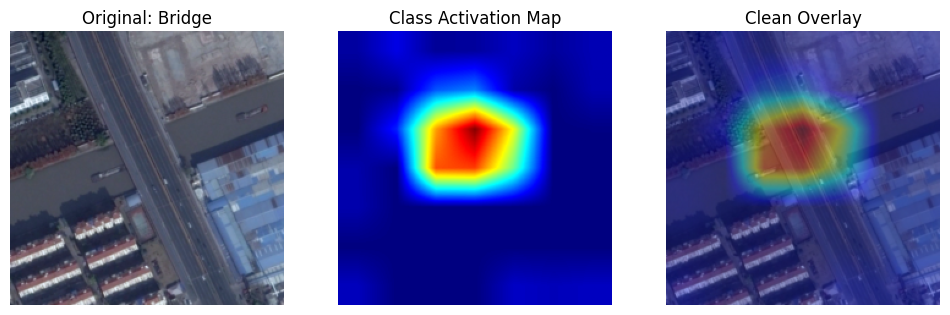

--- Grad-CAM: Noisy Image (Sigma 0.2) ---


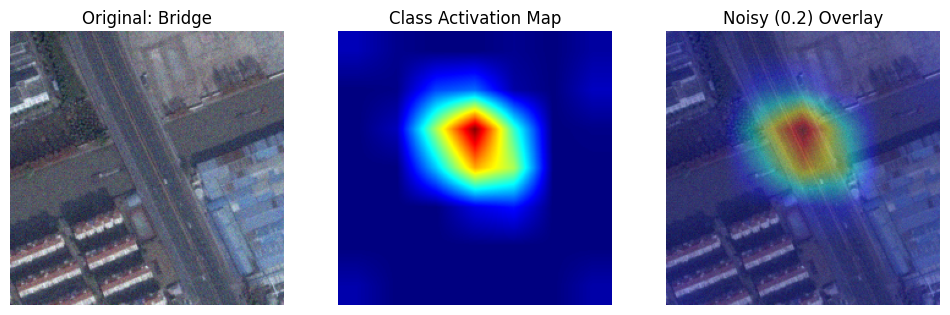

In [5]:
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks to capture forward activations and backward gradients
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, target_class):
        # Forward pass
        model_output = self.model(input_tensor)
        self.model.zero_grad()
        
        # Backward pass for the specific class
        one_hot_output = torch.zeros((1, model_output.size()[-1]), device=DEVICE)
        one_hot_output[0][target_class] = 1
        model_output.backward(gradient=one_hot_output, retain_graph=True)

        # Weight the channels by the average gradient
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # ReLU and Normalization
        cam = F.relu(cam)
        cam -= torch.min(cam)
        cam /= torch.max(cam)
        return cam.cpu().detach().numpy()

def plot_gradcam(model, image_tensor, label_idx, class_names, title="Grad-CAM"):
    model.eval()
    
    # 1. Handle DataParallel wrapper to get the actual architecture
    raw_model = model.module if hasattr(model, 'module') else model
    model_type = str(type(raw_model)).lower()

    # 2. Identify the correct target layer based on architecture
    if 'convnext' in model_type:
        target_layer = raw_model.stages[-1]
    elif 'resnet' in model_type:
        target_layer = raw_model.layer4
    elif 'efficientnet' in model_type:
        # EfficientNet usually stores blocks in .blocks or .features
        target_layer = raw_model.conv_head if hasattr(raw_model, 'conv_head') else raw_model.blocks[-1]
    else:
        raise AttributeError(f"Could not automatically find target layer for {type(raw_model)}")

    # 3. Generate CAM (Ensure the engine uses the wrapper 'model' for the forward/backward pass)
    cam_engine = GradCAM(model, target_layer)
    mask = cam_engine.generate_cam(image_tensor.unsqueeze(0).to(DEVICE), label_idx)
    
    # ... (rest of your plotting code remains the same)
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    heatmap = cv2.resize(mask, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    superimposed_img = heatmap_color * 0.4 + img * 0.6
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1); plt.imshow(img); plt.title(f"Original: {class_names[label_idx]}"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(heatmap_color); plt.title("Class Activation Map"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(superimposed_img); plt.title(f"{title} Overlay"); plt.axis('off')
    plt.show()


def plot_robustness_gradcam(model, image_tensor, label_idx, class_names):
    """Visualizes Grad-CAM for Clean vs Noisy versions of the same image"""
    # 1. Clean Image
    print("--- Grad-CAM: Clean Image ---")
    plot_gradcam(model, image_tensor, label_idx, class_names, title="Clean")
    
    # 2. Noisy Image (Severity 0.2)
    print("--- Grad-CAM: Noisy Image (Sigma 0.2) ---")
    noisy_img = image_tensor + torch.randn_like(image_tensor) * 0.2
    plot_gradcam(model, noisy_img, label_idx, class_names, title="Noisy (0.2)")

# --- RUNNING THE VISUALIZATION ---

convnext_path = '/kaggle/input/datasets/madhusatyala/gnr638-bestmodels/ConvNeXt_full_best (1).pth'
best_convnext = load_and_clean_weights('convnext_tiny', convnext_path)

# Grab a sample from the validation loader
images, labels = next(iter(val_loader))
sample_idx = 0 # Change this to see different images

# Use your best ConvNeXt model loaded previously
plot_robustness_gradcam(best_convnext, images[0], labels[0].item(), full_dataset.classes)